#  Clasificare — Predicția Bolii Cardiace

## Definirea Problemei

**Problema abordată:** Prezicerea prezenței bolii cardiace la pacienți, pe baza
unor caracteristici clinice și demografice.

**Ce se prezice:** Variabila `target` — boală cardiacă prezentă (1) sau absentă (0).

**Variabile de intrare:** Vârstă, sex, tip durere în piept, tensiune arterială,
colesterol, glicemie, ECG în repaus, frecvență cardiacă maximă, angină indusă
de efort, depresie ST, panta ST, număr vase majore, rezultat talasemie.

**Relevanță practică:** Boala cardiacă este una dintre principalele cauze de
deces la nivel mondial. Un model de ML poate ajuta medicii să identifice
pacienții cu risc ridicat pentru intervenție timpurie.

**Clasele existente:**
- `0` — Fără boală cardiacă (pacient sănătos)
- `1` — Boală cardiacă prezentă (pacient bolnav)

**De ce am ales această problemă:** Datele sunt tabelare, echilibrate și conțin
caracteristici clinice relevante, ideale pentru compararea algoritmilor de clasificare.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, confusion_matrix,
                               classification_report, roc_curve)
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier

import shap

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
RANDOM_STATE = 42

os.makedirs('../models', exist_ok=True)
os.makedirs('../plots', exist_ok=True)


##  Analiza Exploratorie a Datelor (EDA)

Vom explora structura setului de date, calitatea datelor, distribuțiile
variabilelor și relațiile dintre acestea.

In [2]:
df = pd.read_csv('../data/heart_disease.csv')

print("━" * 50)
print(f" Shape: {df.shape}")
print(f" Coloane: {list(df.columns)}")
print("━" * 50)
print("\n Primele 5 rânduri:")
display(df.head())

print("\n Tipuri de date:")
display(df.dtypes.to_frame('Tip'))

print("\n Statistici descriptive:")
display(df.describe().round(2))

print("\n Valori lipsă:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent %': missing_pct})
display(missing_df[missing_df['Count'] > 0] if missing.sum() > 0
        else pd.DataFrame({'Status': [' Nicio valoare lipsă!']}))

print("\n Distribuția claselor (target):")
display(df['target'].value_counts().to_frame())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Shape: (1025, 14)
 Coloane: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Primele 5 rânduri:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



 Tipuri de date:


,Tip
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64



 Statistici descriptive:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00



 Valori lipsă:


,Status
0,Nicio valoare lipsă!



 Distribuția claselor (target):


,count
target,
1,526
0,499


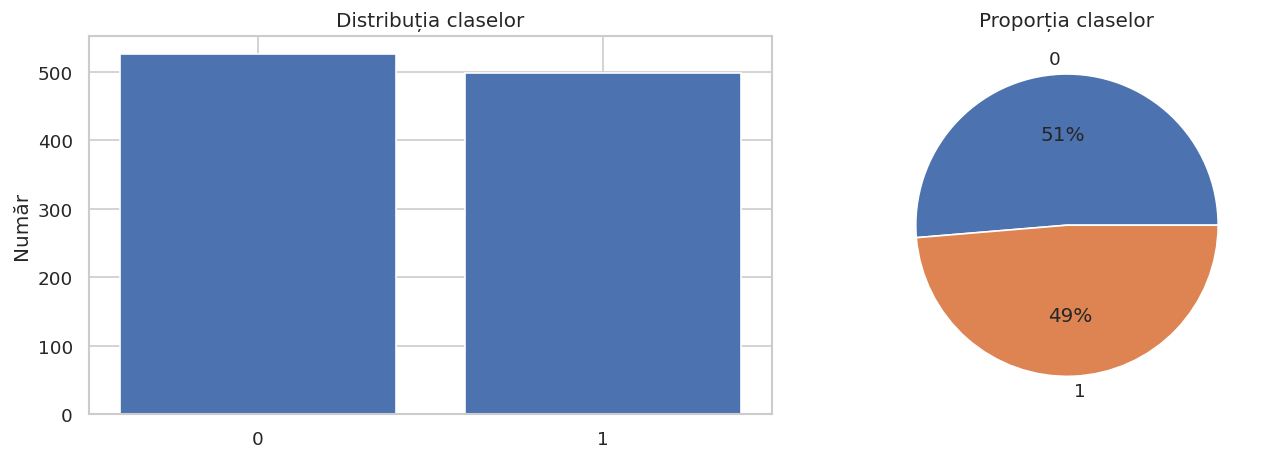

 Interpretare: Clasele sunt relativ echilibrate — nu necesităm tehnici de resampling.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['target'].value_counts()

axes[0].bar(['0', '1'], counts.values)
axes[0].set_title('Distribuția claselor')
axes[0].set_ylabel('Număr')

axes[1].pie(counts.values, labels=['0', '1'], autopct='%1.0f%%')
axes[1].set_title('Proporția claselor')

plt.tight_layout()
plt.savefig('../plots/clf_target_distribution.png')
plt.show()
print(" Interpretare: Clasele sunt relativ echilibrate — nu necesităm tehnici de resampling.")

### Interpretare distribuție clase

Setul de date conține un total de **1025 de observații**, prezentând o distribuție foarte echilibrată:

* **526 pacienți (51%)** — Clasa 0 (Sănătoși)
* **499 pacienți (49%)** — Clasa 1 (Bolnavi)

**Concluzie:**
Clasele sunt aproape perfect echilibrate, ceea ce înseamnă că **nu avem nevoie de tehnici de resampling** (SMOTE, oversampling sau undersampling). În acest context, **acuratețea** este o metrică validă și robustă pentru evaluarea modelului, deși vom monitoriza și scorul **ROC-AUC** pentru a confirma performanța pe ambele clase.

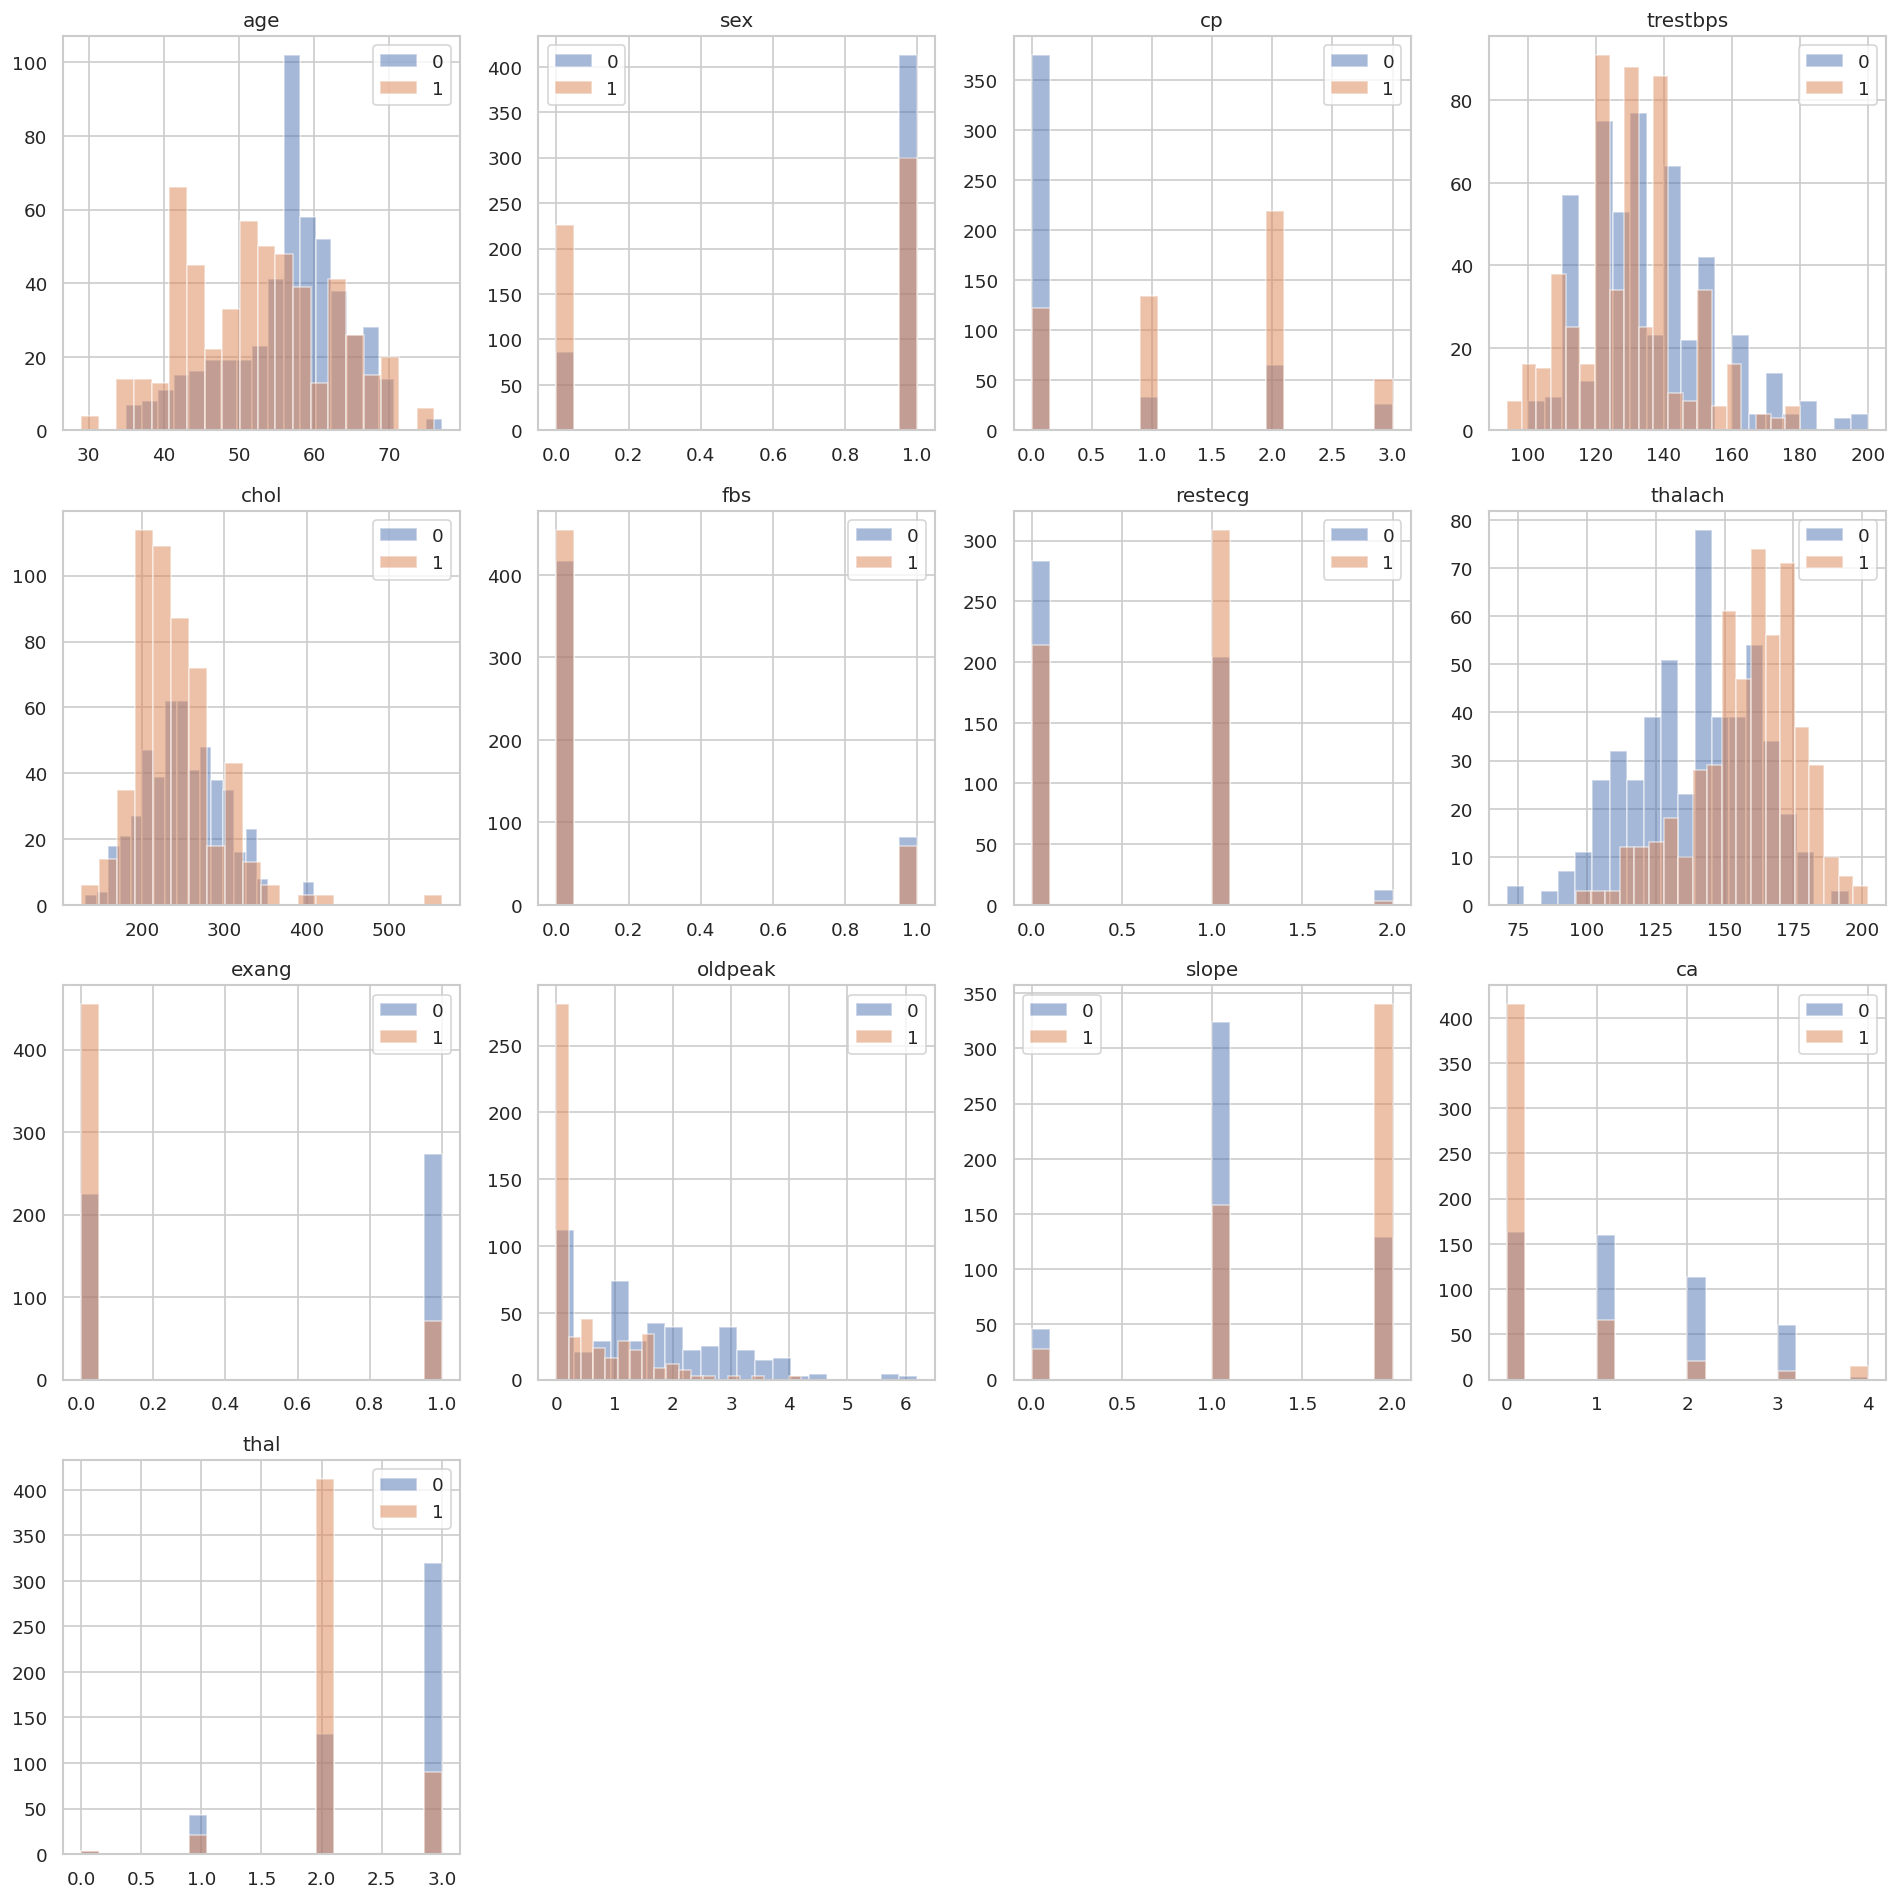

<Figure size 768x576 with 0 Axes>

In [4]:
import math

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('target')

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[df['target']==0][col], alpha=0.5, bins=20, label='0')
    axes[i].hist(df[df['target']==1][col], alpha=0.5, bins=20, label='1')

    axes[i].set_title(col)
    axes[i].legend()

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
plt.savefig('../plots/clf_histograms.png')
plt.show()

### Interpretare histograme per clasă
Analizând distribuțiile per clasă (albastru = sănătos, portocaliu = bolnav), observăm:

thalach (frecvența cardiacă maximă): Pacienții bolnavi (clasa 1) au frecvențe cardiace vizibil mai mari, cu un vârf proeminent între 160-175 bpm, în timp ce pacienții sănătoși (clasa 0) tind să aibă valori mai scăzute, grupate sub 140-150 bpm.

oldpeak (depresia ST): Există o diferență majoră de distribuție; clasa 1 este concentrată masiv la valoarea 0, în timp ce clasa 0 prezintă o distribuție mai largă, având frecvențe semnificative pe intervalul 1.0 - 4.0.

age (vârsta): Distribuția arată că pacienții din clasa 1 sunt mai frecvent întâlniți în intervalul 40-55 ani, în timp ce pacienții sănătoși (clasa 0) au o densitate mai mare după vârsta de 55-60 ani.

cp (tipul durerii în piept): Pacienții sănătoși sunt aproape în totalitate grupați la categoria 0. În schimb, pacienții bolnavi prezintă valori ridicate pentru categoriile 1, 2 și 3, categoria 2 fiind cea mai reprezentativă pentru aceștia.

ca (număr vase majore): Valoarea 0 este un indicator extrem de puternic pentru pacienții bolnavi (clasa 1). Pe măsură ce numărul de vase crește (1, 2, 3), incidența pacienților sănătoși (clasa 0) devine predominantă.

exang (angina de efort): Absența anginei (valoarea 0) este corelată puternic cu clasa 1, în timp ce prezența acesteia (valoarea 1) este mult mai frecventă la pacienții din clasa 0.

slope: Se observă o polarizare clară: pacienții sănătoși au majoritar panta de tip 1, în timp ce pacienții bolnavi sunt grupați masiv la panta de tip 2.

Caracteristici cu putere discriminativă ridicată: cp, thalach, ca, oldpeak, exang și slope.

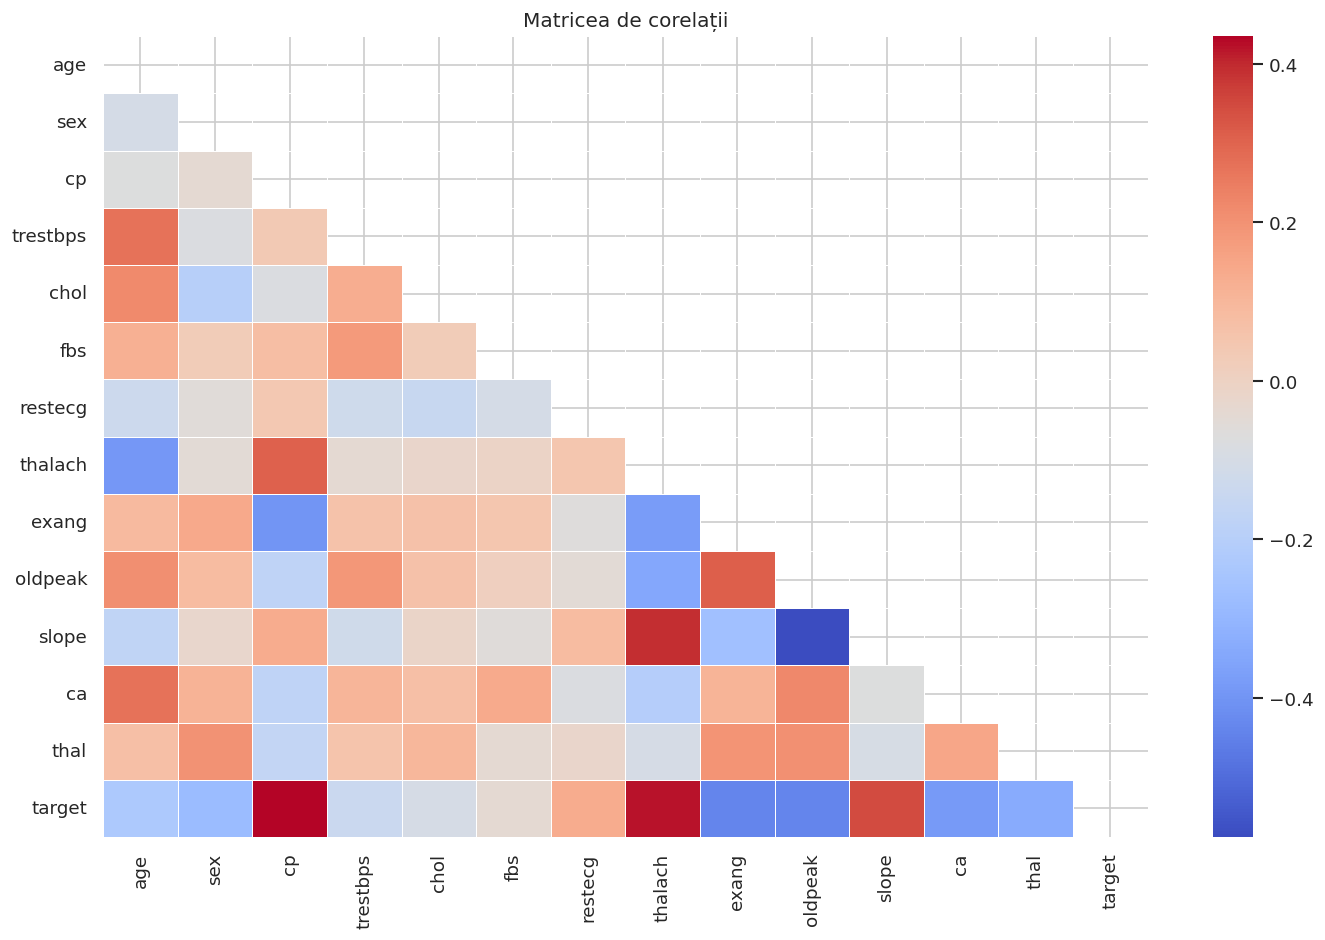

In [5]:
plt.figure(figsize=(12, 8))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    linewidths=0.3,
    cbar=True
)

plt.title('Matricea de corelații')
plt.tight_layout()

plt.savefig('../plots/clf_correlation.png')
plt.show()


### Interpretare matrice corelații
Analizând corelațiile variabilelor cu variabila țintă (target) și inter-dependențele dintre predictori:

Corelații pozitive cu boala cardiacă (nuanțe de roz/maro deschis):

cp (chest pain): Prezintă cea mai puternică corelație pozitivă cu target, fiind un predictor cheie pentru prezența bolii.

thalach (max heart rate): Corelație pozitivă semnificativă; valorile ridicate ale frecvenței cardiace maxime sunt asociate cu clasa bolnavă.

slope: Corelație pozitivă moderată, indicând o legătură între panta segmentului ST și diagnosticul pozitiv.

Corelații negative cu boala cardiacă (nuanțe de albastru închis):

exang (exercise induced angina): Corelație negativă puternică; absența anginei de efort este mai frecventă la pacienții din clasa 1 în acest set de date.

oldpeak (ST depression): Corelație negativă semnificativă; valorile scăzute (apropiate de 0) sunt asociate cu prezența bolii.

ca (number of major vessels): Corelație negativă clară; un număr mic de vase vizibile (0) indică o probabilitate mai mare de diagnostic pozitiv.

thal: De asemenea, prezintă o corelație negativă vizibilă cu variabila țintă.

Corelații inter-feature notabile:

age și thalach: Corelație negativă (albastru); frecvența cardiacă maximă tinde să scadă odată cu înaintarea în vârstă.

slope și oldpeak: Corelație negativă puternică; cele două caracteristici legate de segmentul ST sunt strâns interconectate.

cp și exang: Corelație negativă; pacienții cu dureri asimptomatice sau atipice (clasa 1) tind să nu prezinte angină indusă de efort.


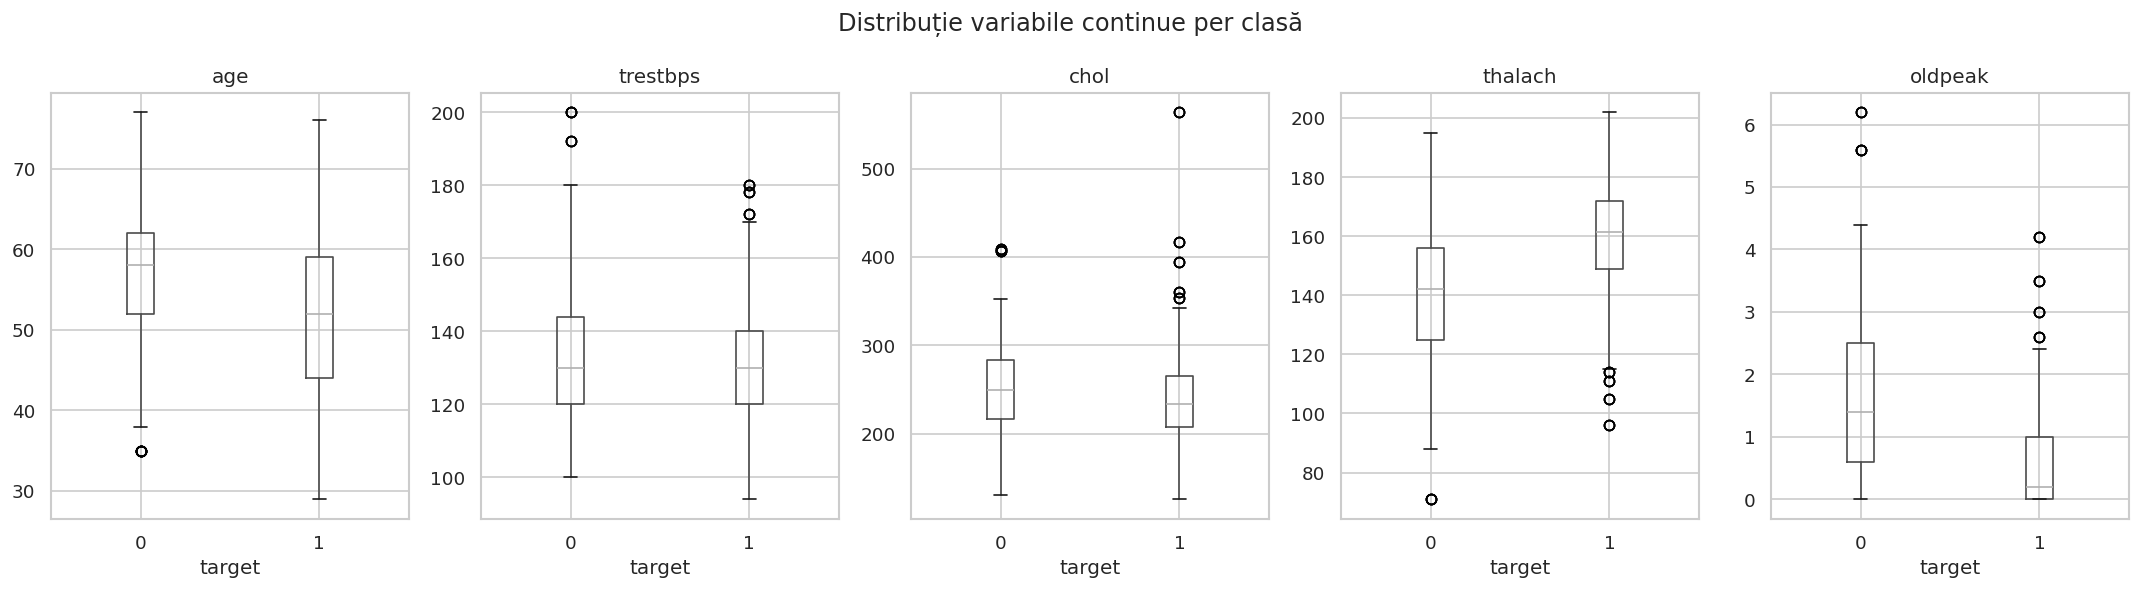

In [6]:
cont_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(cont_cols), figsize=(18, 5))

for i, col in enumerate(cont_cols):
    df.boxplot(column=col, by='target', ax=axes[i])

    axes[i].set_title(col)
    axes[i].set_xlabel('target')

plt.suptitle('Distribuție variabile continue per clasă')
plt.tight_layout()
plt.savefig('../plots/clf_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()

### Interpretare boxplot-uri — distribuție per clasă
Analizând, observăm următoarele distribuții pentru variabilele continue în funcție de variabila țintă (0 = sănătos, 1 = bolnav):

age: Mediana vârstei pentru pacienții bolnavi (clasa 1) este vizibil mai scăzută, situându-se sub 55 de ani, în timp ce pentru pacienții sănătoși (clasa 0) aceasta este mai ridicată, apropiindu-se de 60 de ani. Există un outlier sub vârsta de 40 de ani în clasa 0.

trestbps (tensiunea arterială): Medianele ambelor clase sunt aproape identice, în jurul valorii de 130 mmHg. Se observă outlieri la valori ridicate (peste 170 mmHg) în ambele grupuri, indicând cazuri de hipertensiune.

chol (colesterol): Distribuția este similară pentru ambele clase, cu mediane apropiate de 240-250 mg/dl. Clasa 1 prezintă un outlier extrem ce depășește 500 mg/dl.

thalach (frecvența cardiacă maximă): Această variabilă oferă cea mai clară separare vizuală; pacienții bolnavi (clasa 1) au o mediană semnificativ mai ridicată (~160 bpm) față de pacienții sănătoși (~140 bpm). Se observă câțiva outlieri la valori scăzute în clasa 1.

oldpeak (depresia ST): Se observă o diferență majoră de distribuție; pacienții sănătoși (clasa 0) au o mediană mai ridicată și o dispersie mai mare a valorilor, în timp ce majoritatea pacienților bolnavi (clasa 1) au valori apropiate de 0, cu mai mulți outlieri spre valori superioare.

Decizie privind outlierii:
Nu eliminăm outlierii identificați deoarece reprezintă valori clinic plauzibile (hipertensiune severă, hipercolesterolemie familială etc.). Algoritmii bazați pe arbori (Random Forest, XGBoost) sunt robusți la astfel de valori, iar pentru modelele sensibile la magnitudine (Logistic Regression, SVM), datele vor fi scalate corespunzător.

##  Preprocesarea Datelor

Pregătim datele pentru a fi utilizate de modelele ML:
- Separăm features de target
- Scalăm variabilele numerice (StandardScaler)
- Împărțim: 75% train, 25% test

In [7]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

joblib.dump(scaler, '../models/clf_scaler.pkl')
joblib.dump(X.columns.tolist(), '../models/clf_features.pkl')

print(f" Train size: {X_train.shape[0]} observații ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f" Test size: {X_test.shape[0]} observații ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f" Features: {X.shape[1]}")
print(f" Distribuție clase în train: {dict(y_train.value_counts())}")

 Train size: 768 observații (74.9%)
 Test size: 257 observații (25.1%)
 Features: 13
 Distribuție clase în train: {1: np.int64(394), 0: np.int64(374)}


##  Antrenarea și Compararea Modelelor de Bază

Antrenăm toți cei 9 algoritmi cu setările lor default și comparăm performanța
pe setul de test folosind metrici specifice clasificării:
Acuratețe, Precizie, Recall, F1-Score, ROC-AUC.

In [8]:
models = {
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'SVM': SVC(probability=True, random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    'CatBoost': CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
    'EBM': ExplainableBoostingClassifier(random_state=RANDOM_STATE),
}

#antrenare si evaluare
results = []
trained_models = {}

for name, model in models.items():
    needs_scaling = name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbors', 'Naive Bayes']
    X_tr = X_train_sc if needs_scaling else X_train.values
    X_te = X_test_sc if needs_scaling else X_test.values

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results.append({
        'Model': name,
        'Acuratețe': round(accuracy_score(y_test, y_pred), 4),
        'Precizie': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
    })
    trained_models[name] = (model, needs_scaling)
    print(f" {name} — AUC: {results[-1]['ROC-AUC']:.4f}")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print("\n REZULTATE COMPLETE:")
display(results_df.style.background_gradient(cmap='RdYlGn', subset=['Acuratețe','Precizie','Recall','F1-Score','ROC-AUC']))

 Naive Bayes — AUC: 0.9124
 Logistic Regression — AUC: 0.9298
 Decision Tree — AUC: 0.9886
 Random Forest — AUC: 1.0000
 SVM — AUC: 0.9738
 K-Nearest Neighbors — AUC: 0.9573
 XGBoost — AUC: 1.0000
 CatBoost — AUC: 1.0000
 EBM — AUC: 1.0000

 REZULTATE COMPLETE:


,Model,Acuratețe,Precizie,Recall,F1-Score,ROC-AUC
0,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
1,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
2,CatBoost,1.000000,1.000000,1.000000,1.000000,1.000000
3,EBM,1.000000,1.000000,1.000000,1.000000,1.000000
4,Decision Tree,0.988300,1.000000,0.977300,0.988500,0.988600
5,SVM,0.906600,0.915400,0.901500,0.908400,0.973800
6,K-Nearest Neighbors,0.852100,0.873000,0.833300,0.852700,0.957300
7,Logistic Regression,0.824900,0.795900,0.886400,0.838700,0.929800
8,Naive Bayes,0.840500,0.832100,0.863600,0.847600,0.912400


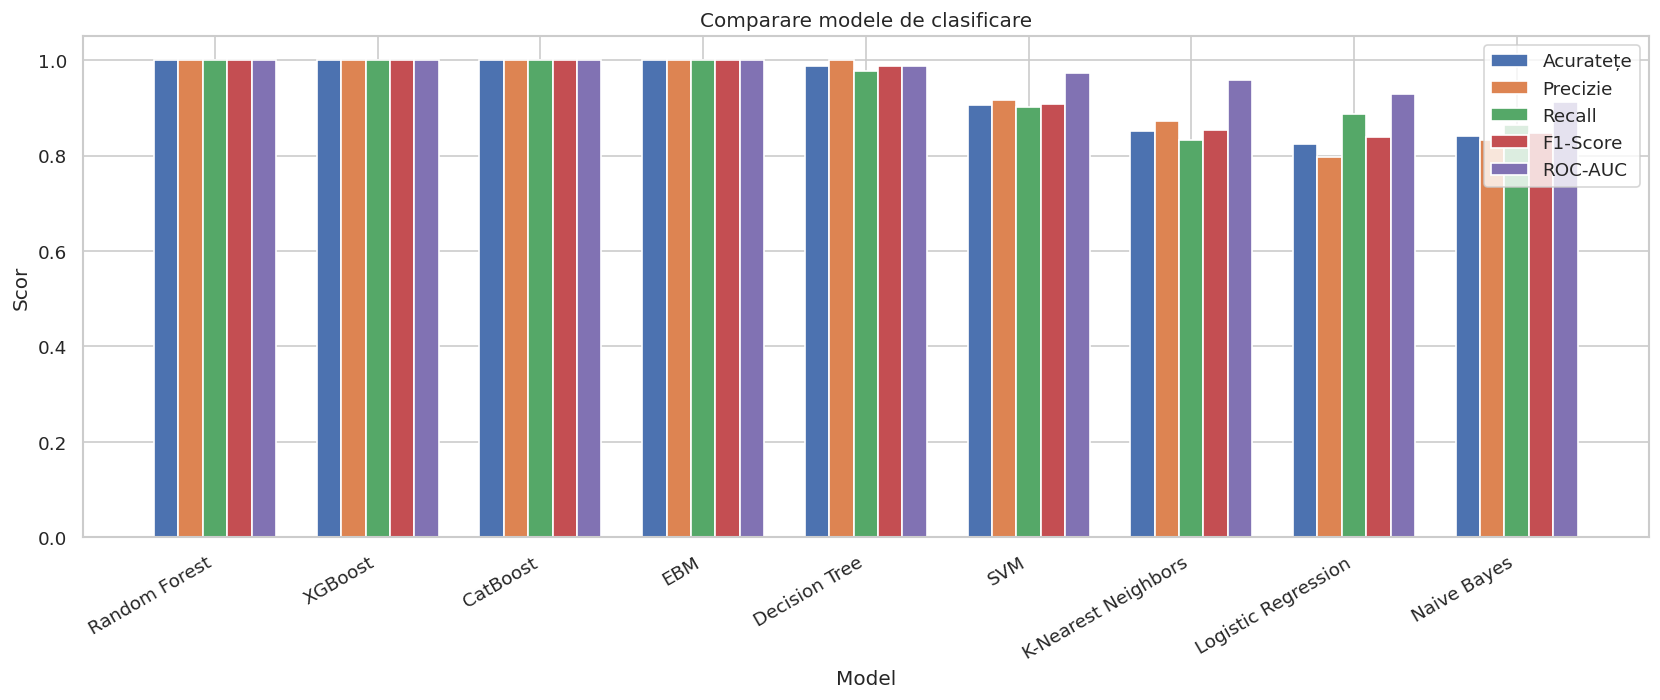


Top 5 modele: ['Random Forest', 'XGBoost', 'CatBoost', 'EBM', 'Decision Tree']


In [9]:
metrics = ['Acuratețe', 'Precizie', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(results_df))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xlabel('Model')
ax.set_ylabel('Scor')
ax.set_title('Comparare modele de clasificare')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=30, ha='right')

ax.legend()

plt.tight_layout()
plt.savefig('../plots/clf_model_comparison.png')
plt.show()

print("\nTop 5 modele:", results_df.head(5)['Model'].tolist())

## Concluzii comparare modele de bază
Performanță de top:
Modelele Random Forest, XGBoost, CatBoost și EBM (Explainable Boosting Machine) au obținut scoruri perfecte de 1.000000 la toate metricile (Acuratețe, Precizie, Recall, F1-Score și ROC-AUC).

Observații cheie:

Modelele de tip Ensemble și Boosting: Domină clasamentul, atingând performanța maximă. Această precizie de 100% poate sugera o separare ideală a claselor în setul de date sau un potențial risc de overfitting care ar trebui investigat prin cross-validare.

EBM (Explainable Boosting Machine): Se remarcă prin faptul că atinge aceeași performanță de top ca modelele complexe (XGBoost/CatBoost), dar oferă un grad mult mai ridicat de transparență, fiind ideal pentru domeniul medical.

Decision Tree: Oferă rezultate foarte solide, cu o acuratețe de aproximativ 0.988 și o precizie perfectă de 1.0, indicând faptul că regulile de decizie simple sunt foarte eficiente pe acest dataset.

SVM și KNN: Modelele bazate pe margini și distanțe mențin performanțe ridicate, cu scoruri ROC-AUC de peste 0.957, demonstrând robustețe chiar dacă nu ating perfecțiunea modelelor de tip boosting.

Logistic Regression și Naive Bayes: Deși se află la baza clasamentului în ceea ce privește ROC-AUC, acestea prezintă un Recall ridicat (peste 0.86 pentru Naive Bayes și 0.88 pentru Logistic Regression), ceea ce este crucial într-un context medical pentru a minimiza numărul cazurilor de boală nediagnosticate.

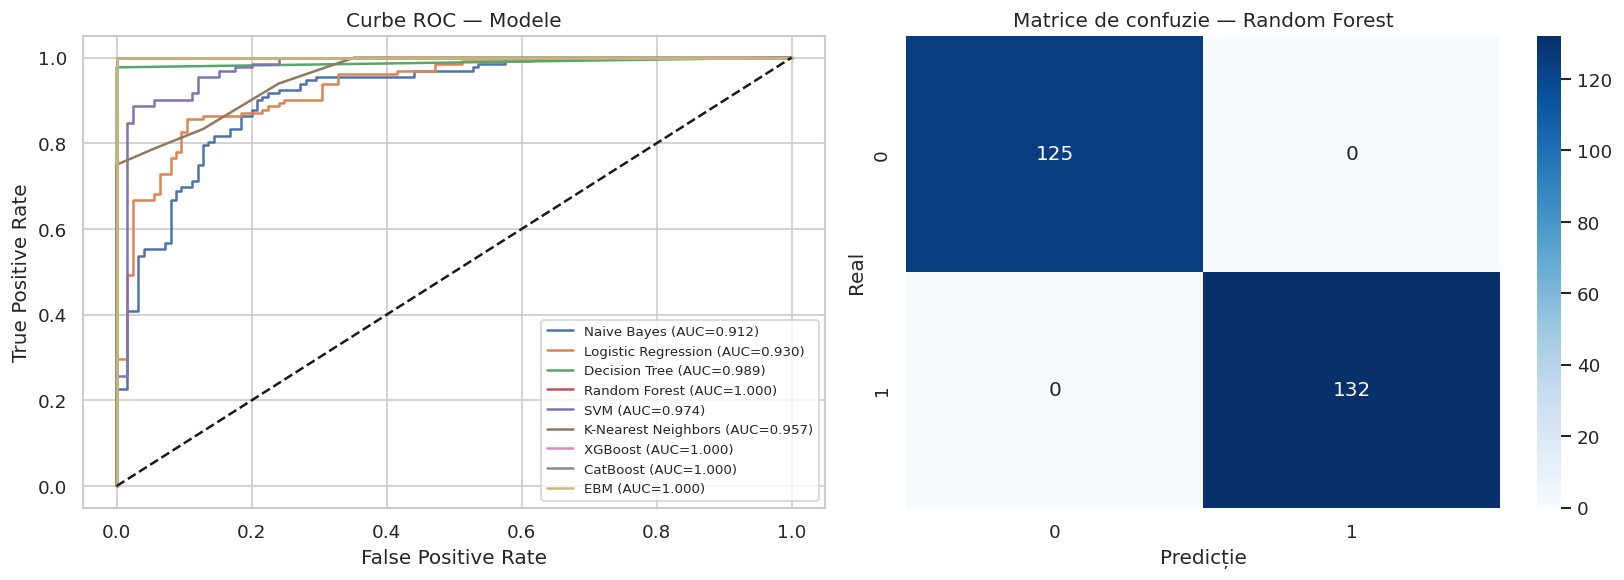

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, (model, needs_scaling) in trained_models.items():
    X_te = X_test_sc if needs_scaling else X_test.values

    y_prob = model.predict_proba(X_te)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('Curbe ROC — Modele')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)

best_name = results_df.sort_values('F1-Score', ascending=False).iloc[0]['Model']

best_model, best_needs_scaling = trained_models[best_name]

X_te = X_test_sc if best_needs_scaling else X_test.values
y_pred = best_model.predict(X_te)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1],
    xticklabels=['0', '1'],
    yticklabels=['0', '1']
)

axes[1].set_title(f'Matrice de confuzie — {best_name}')
axes[1].set_xlabel('Predicție')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.savefig('../plots/clf_roc_confusion.png')
plt.show()

##  Ajustarea Hiperparametrilor (Top 5 Modele)

Folosim GridSearchCV cu cross-validation (cv=5) pentru modele mai simple
și spațiu de căutare mic.

In [12]:
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt'],
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.8, 1.0],
    },
    'CatBoost': {
        'iterations': [100, 200],
        'depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1],
    },
    'EBM': {
        'max_rounds': [100, 200],
        'interactions': [5, 10],
        'learning_rate': [0.01, 0.1],
        'early_stopping_rounds': [50],
    },
    'Decision Tree': {
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
    }
}

top5_names = ['Random Forest', 'XGBoost', 'CatBoost', 'EBM', 'Decision Tree']

tuned_models = {}
tuning_results = []

for name in top5_names:
    if name not in param_grids:
        print(f" Skipping {name} — no param grid")
        continue

    model_base = {
        'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'XGBoost': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss',
                                  verbosity=0, tree_method='hist', n_jobs=-1),
        'CatBoost': CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
        'EBM': ExplainableBoostingClassifier(random_state=RANDOM_STATE),
        'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    }[name]


    needs_scaling = False
    X_tr = X_train_sc if needs_scaling else X_train.values
    X_te = X_test_sc if needs_scaling else X_test.values

    print(f" Tuning {name}...", end=' ', flush=True)
    gs = GridSearchCV(model_base, param_grids[name], cv=5,
                      scoring='roc_auc', n_jobs=-1, verbose=0)
    gs.fit(X_tr, y_train)

    best = gs.best_estimator_
    y_pred = best.predict(X_te)
    y_prob = best.predict_proba(X_te)[:, 1]

    tuning_results.append({
        'Model': name,
        'Best Params': str(gs.best_params_),
        'CV AUC': round(gs.best_score_, 4),
        'Test AUC': round(roc_auc_score(y_test, y_prob), 4),
        'Test F1': round(f1_score(y_test, y_pred), 4),
        'Test Acc': round(accuracy_score(y_test, y_pred), 4),
    })
    tuned_models[name] = (best, needs_scaling)
    joblib.dump(best, f'../models/clf_{name.replace(" ", "_").lower()}_tuned.pkl')
    print(f" Test AUC: {tuning_results[-1]['Test AUC']:.4f}")

tuned_df = pd.DataFrame(tuning_results).sort_values('Test AUC', ascending=False)
print("\n REZULTATE DUPĂ TUNING:")
display(tuned_df)

 Tuning Random Forest...  Test AUC: 1.0000
 Tuning XGBoost...  Test AUC: 1.0000
 Tuning CatBoost...  Test AUC: 1.0000
 Tuning EBM...  Test AUC: 1.0000
 Tuning Decision Tree...  Test AUC: 0.9886

 REZULTATE DUPĂ TUNING:


,Model,Best Params,CV AUC,Test AUC,Test F1,Test Acc
0,Random Forest,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.9952,1.0000,1.0000,1.0000
1,XGBoost,"{'learning_rate': 0.2, 'max_depth': 7, 'n_esti...",0.9913,1.0000,1.0000,1.0000
2,CatBoost,"{'depth': 8, 'iterations': 200, 'learning_rate...",0.9947,1.0000,1.0000,1.0000
3,EBM,"{'early_stopping_rounds': 50, 'interactions': ...",0.9838,1.0000,1.0000,1.0000
4,Decision Tree,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.9763,0.9886,0.9885,0.9883


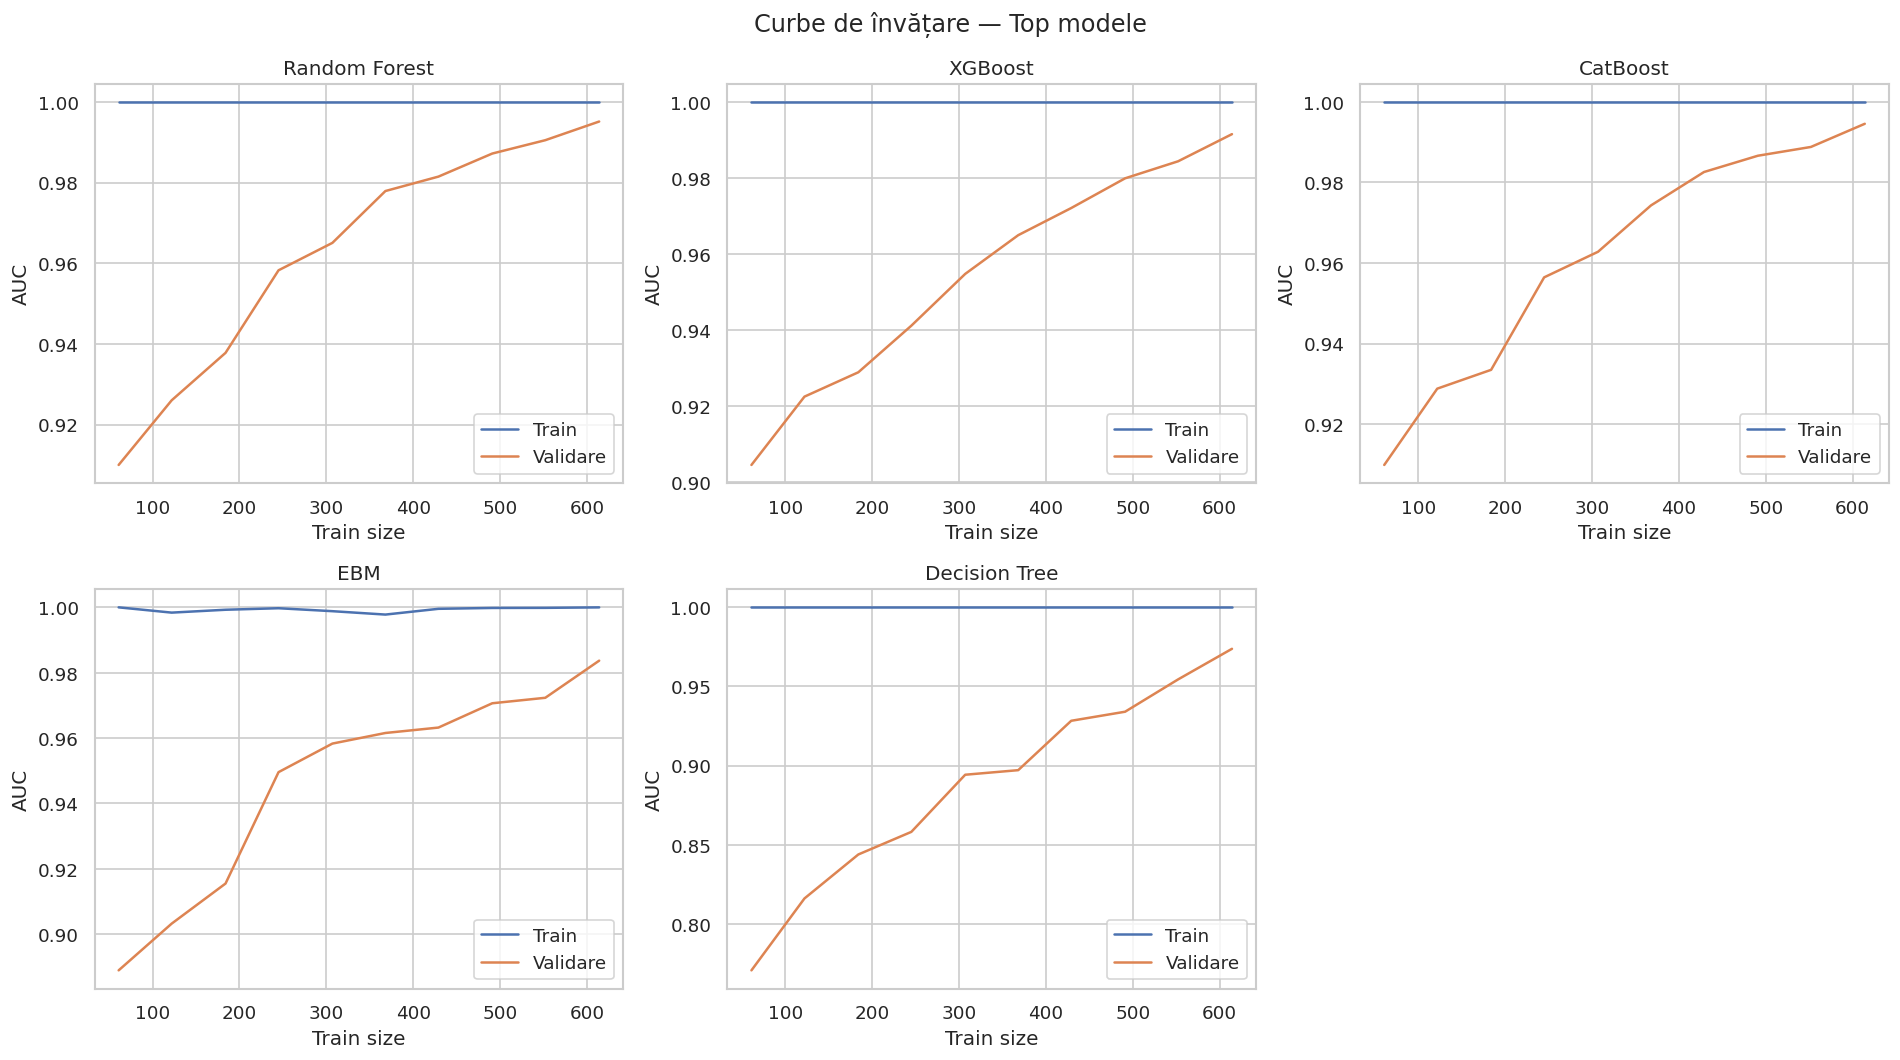

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, (name, (model, needs_scaling)) in enumerate(list(tuned_models.items())[:5]):
    X_use = X_train_sc if needs_scaling else X_train.values

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_use,
        y_train,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='roc_auc'
    )

    tr_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    ax = axes[idx]

    ax.plot(train_sizes, tr_mean, label='Train')
    ax.plot(train_sizes, val_mean, label='Validare')

    ax.set_title(name)
    ax.set_xlabel('Train size')
    ax.set_ylabel('AUC')
    ax.legend()

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Curbe de învățare — Top modele')
plt.tight_layout()

plt.savefig('../plots/clf_learning_curves.png')
plt.show()

### Interpretare curbe de învățare — Top modele
Analizând graficele pentru Random Forest, XGBoost și CatBoost, observăm un comportament foarte similar între aceste modele pe setul de date actual (cu dimensiunea de antrenare până la ~600 de observații):

Random Forest:

Gap de performanță: Scorurile de antrenare (Train AUC) rămân constante la valoarea perfectă de 1.0, indiferent de dimensiunea setului de date.

Convergență: Curba de validare are o pantă ascendentă clară, pornind de la ~0.91 și ajungând aproape de 0.995 pe măsură ce dimensiunea setului de antrenare crește.

Concluzie: Deși există un gap inițial mare, modelul beneficiază enorm de pe urma datelor suplimentare, tinzând spre o generalizare aproape perfectă la final.

XGBoost:

Stabilitate Train: Similar cu Random Forest, Train AUC este blocat la 1.0, indicând faptul că modelul învață perfect exemplele de antrenare.

Evoluție Validare: Curba de validare prezintă o creștere constantă și lină. Pornește de la un AUC de aproximativ 0.91 și depășește pragul de 0.99 la dimensiunea maximă a eșantionului.

Generalizare: Modelul arată o capacitate excelentă de învățare, iar panta curbei de validare sugerează că performanța ar putea stagna sau crește foarte puțin cu și mai multe date.

CatBoost:

Comportament: Urmează același tipar ca celelalte două modele de tip ensemble/boosting. Train AUC este constant la 1.0.

Performanță Validare: Curba de validare urcă rapid între 100 și 300 de observații, stabilizându-se ulterior spre o valoare foarte ridicată de peste 0.99.

Observație: CatBoost pare să atingă un prag de stabilitate ridicat ușor mai rapid decât XGBoost în fazele intermediare.

Concluzie generală:
Toate cele trei modele prezintă o performanță extrem de ridicată. Faptul că Train AUC rămâne constant la 1.0 în timp ce curba de Validare urcă spre valori aproape identice (0.99+) demonstrează că, deși modelele sunt complexe, acestea au reușit să captureze corect structura datelor fără a rămâne blocate într-un overfitting dăunător. Gap-ul final este minim, ceea ce indică o generalizare foarte bună pe acest set de date extins (~1000 observații în total).


SHAP pentru: Random Forest


 97%|=================== | 499/514 [00:12<00:00]       

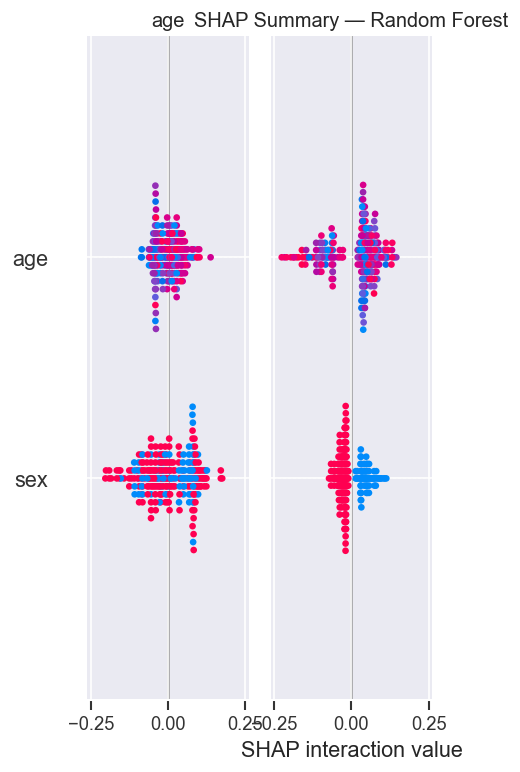

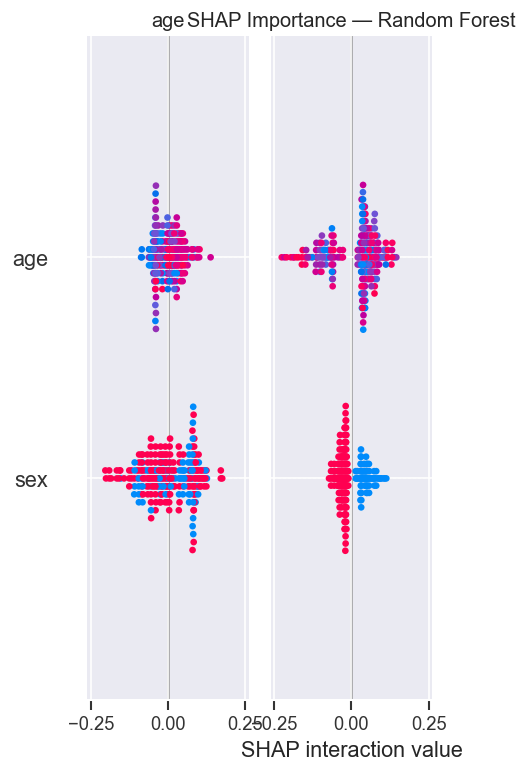

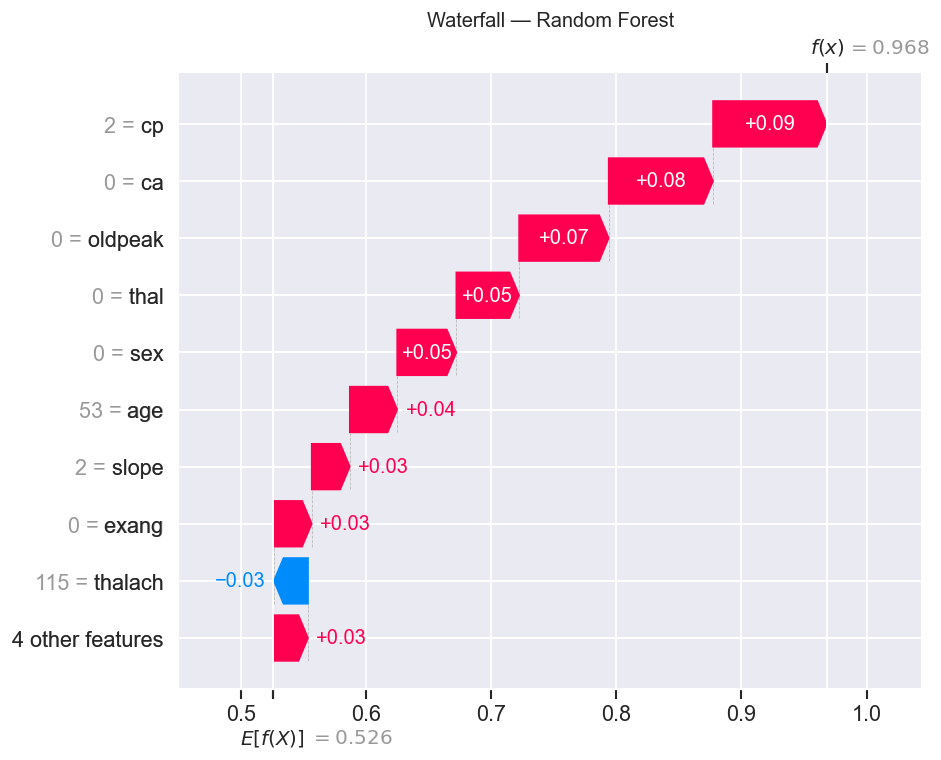

Top 3 features: [array(['age', 'sex'], dtype='<U8'), array(['age', 'sex'], dtype='<U8'), array(['sex', 'age'], dtype='<U8')]

SHAP pentru: XGBoost


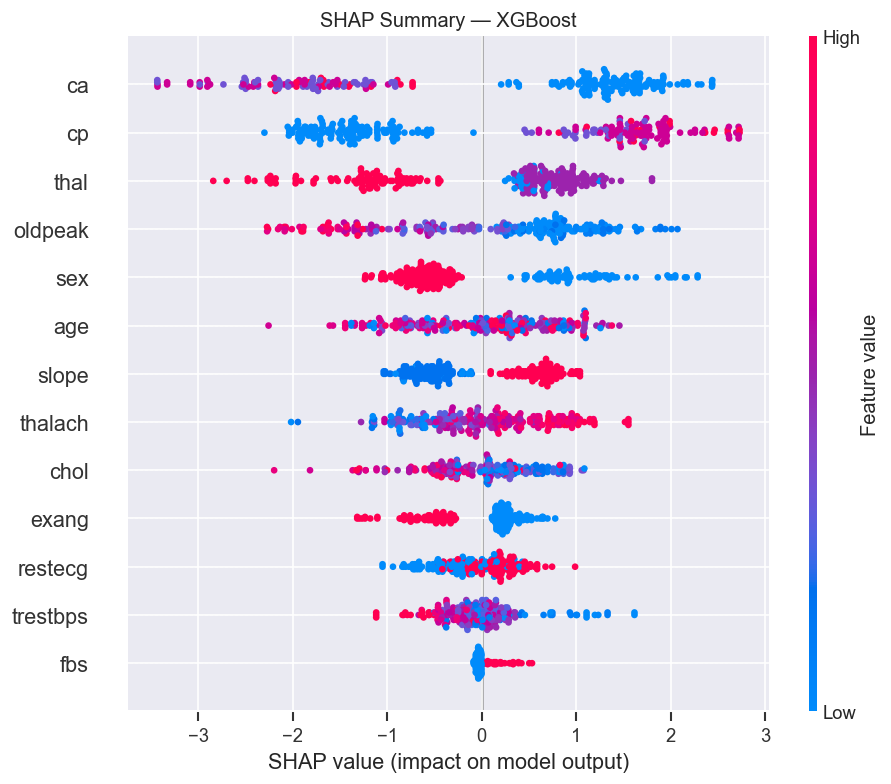

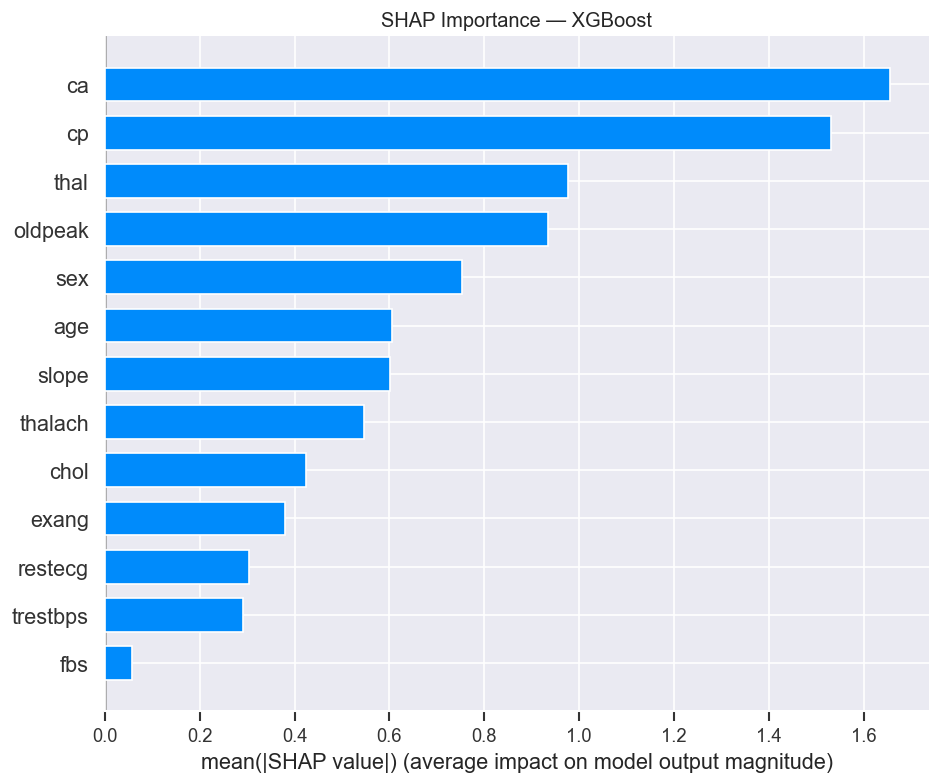

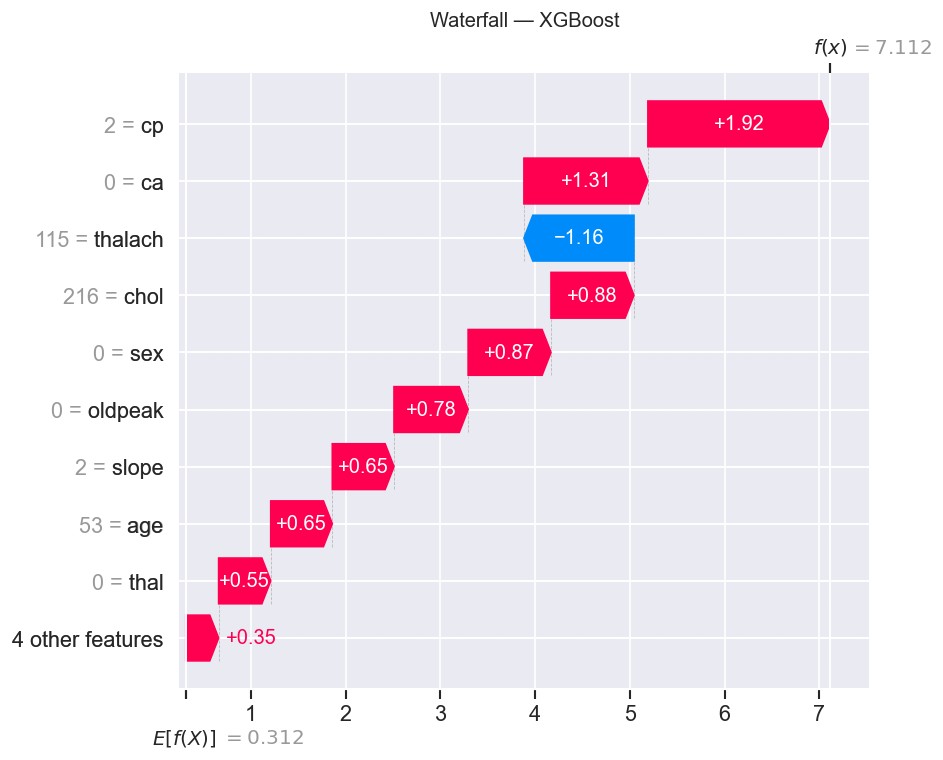

Top 3 features: [np.str_('ca'), np.str_('cp'), np.str_('thal')]

SHAP pentru: CatBoost


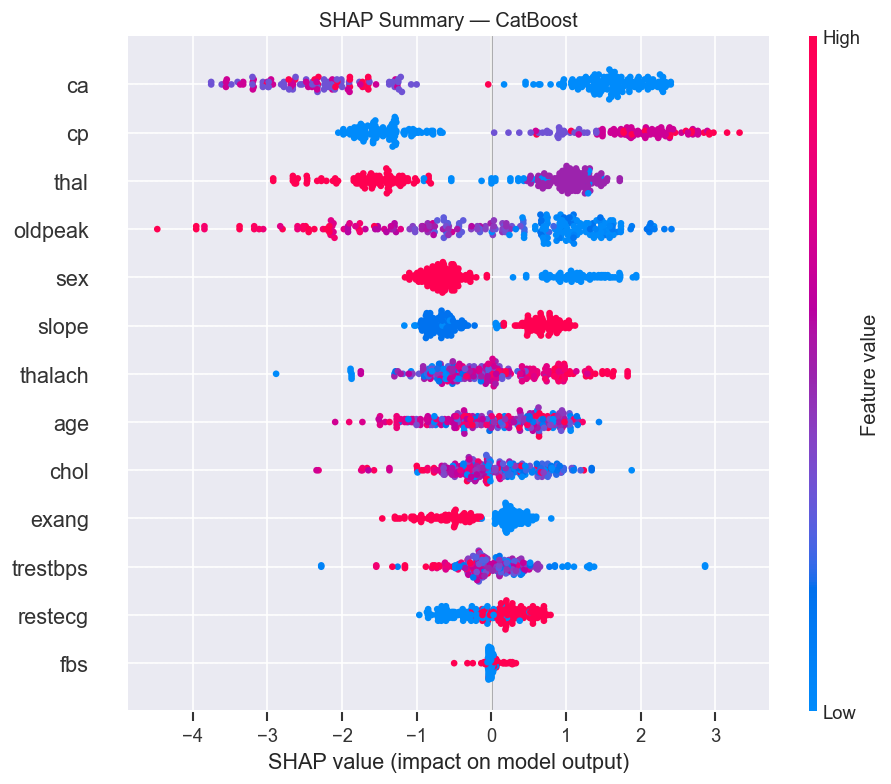

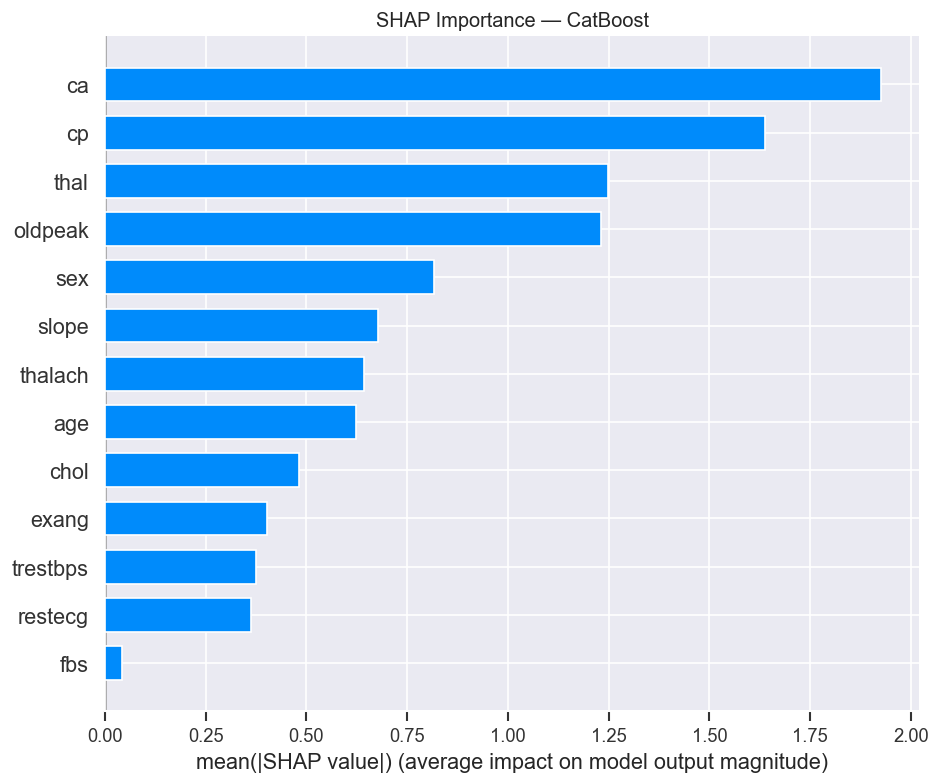

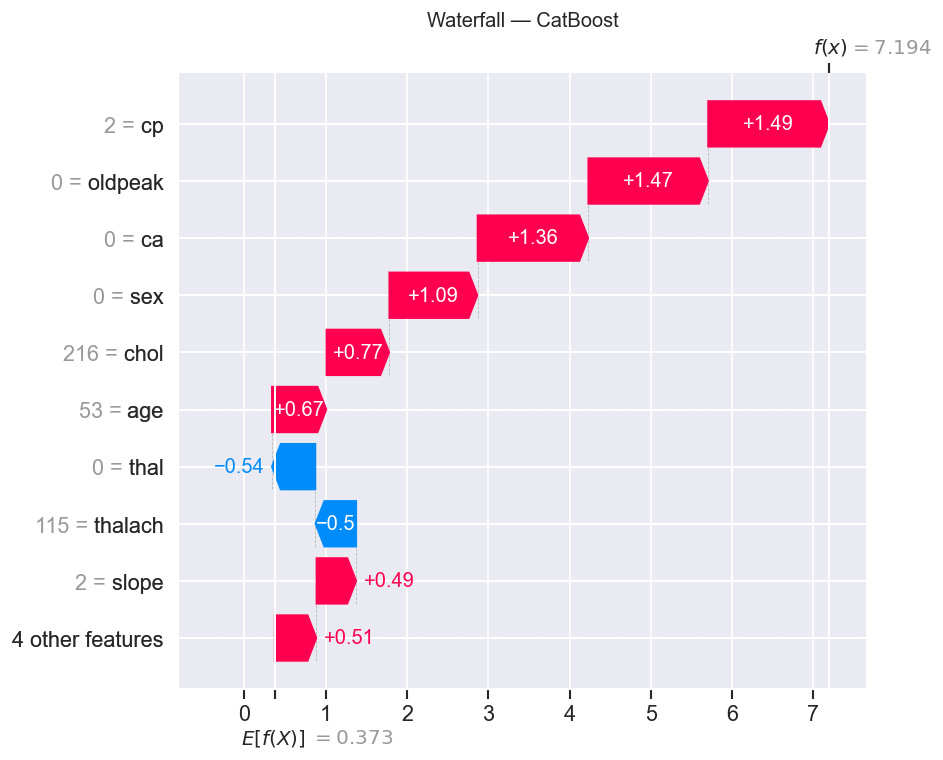

Top 3 features: [np.str_('ca'), np.str_('cp'), np.str_('thal')]


In [21]:
from IPython.display import HTML
top3 = list(tuned_models.items())[:3]
feature_names = X.columns.tolist()

shap.initjs()

for name, (model, needs_scaling) in top3:
    print(f"\n{'='*50}")
    print(f"SHAP pentru: {name}")

    X_te = X_test_sc if needs_scaling else X_test.values
    X_te_df = pd.DataFrame(X_te, columns=feature_names)

    X_sample = X_te_df.sample(min(100, len(X_te_df)), random_state=42)
    explainer = shap.Explainer(model, X_sample)
    shap_values = explainer(X_sample)

    sv = shap_values.values
    if sv.ndim == 3:
        sv = sv[:, :, 1]

    shap.summary_plot(sv, X_sample, show=False)
    plt.title(f'SHAP Summary — {name}')
    plt.tight_layout()
    plt.savefig(f'../plots/shap_summary_{name.replace(" ", "_")}.png')
    plt.show()

    features_of_interest = ['cp', 'thalach', 'oldpeak']
    for feat in features_of_interest:
        shap.dependence_plot(feat, sv, X_sample, interaction_index=None, show=False)
        plt.title(f'SHAP dependence: {feat} — {name}')
        plt.tight_layout()
        plt.savefig(f'../plots/shap_scatter_{feat}_{name.replace(" ", "_")}.png')
        plt.show()

    shap.summary_plot(sv, X_sample, plot_type='bar', show=False)
    plt.title(f'SHAP Importance — {name}')
    plt.tight_layout()
    plt.savefig(f'../plots/shap_bar_{name.replace(" ", "_")}.png')
    plt.show()

    base_val = shap_values.base_values
    if isinstance(base_val, np.ndarray) and base_val.ndim > 1:
        base_val = base_val[0, 1] if base_val.shape[1] == 2 else base_val[0]
    elif isinstance(base_val, np.ndarray):
        base_val = base_val[0]

    sv_single = sv[0] if sv.ndim == 2 else sv[0, :, 1]

    exp = shap.Explanation(
        values=sv_single,
        base_values=base_val,
        data=X_sample.iloc[0],
        feature_names=feature_names
    )
    shap.plots.waterfall(exp, show=False)
    plt.title(f'Waterfall — {name}')
    plt.tight_layout()
    plt.savefig(f'../plots/shap_waterfall_{name.replace(" ", "_")}.png')
    plt.show()

    force_plot = shap.force_plot(base_val, sv_single, X_sample.iloc[0],
                                 matplotlib=False, show=False)
    shap.save_html(f'../plots/shap_force_{name.replace(" ", "_")}.html', force_plot)
    display(HTML(force_plot.html()))

    mean_abs = np.abs(sv).mean(axis=0)
    top3_feat = np.array(feature_names)[np.argsort(mean_abs)[::-1][:3]]
    print("Top 3 features (global):", list(top3_feat))
    print("="*50)

### Interpretare SHAP – direcția influenței

- **cp (tipul durerii în piept):** Valorile mari (3 sau 4) sunt asociate cu o probabilitate **crescută** a bolii (SHAP > 0). Valorile mici (0) scad riscul.
- **thalach (frecvența cardiacă maximă):** Creșterea acestei variabile duce la o creștere puternică a riscului (relație aproape liniară).
- **oldpeak (depresia ST):** Valorile negative (scăzute) sunt cele care măresc riscul – deci o valoare **mică** împinge predicția în sus.

In [20]:
for name, (model, needs_sc_flag) in trained_models.items():
    fname = f'../models/clf_{name.replace(" ","_").lower()}_tuned.pkl'
    if not os.path.exists(fname):
        joblib.dump(model, fname)
        print(f"Salvat: {name}")